## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Thrace'
NUTS2_ID = 'EL51'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL511,εβρος,26.176106,41.222160,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.293398,-1.643682,1.824858,5.319432,NaN,NaN,NaN,-0.739066,NaN,NaN,NaN,2.290183,NaN,NaN,NaN,7.036106,9.142565e+01,1.297637e+02,2.179013e+02,218.119280,31.387255,1.012492,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,31,36,30,12,12,3,5,8,2,-8.242326,9.934900,218.119280,0,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,NaN,NaN
1,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL512,ξανθη,24.892059,41.169359,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.769895,-1.152583,2.808656,6.769895,NaN,NaN,NaN,-0.479640,NaN,NaN,NaN,3.145128,NaN,NaN,NaN,9.791599,1.392955e+02,2.074087e+02,3.034552e+02,303.539567,31.000000,1.000000,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.0,1.0,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,31,36,30,12,12,3,4,4,2,-5.288987,12.493000,303.539567,0,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,10590.0,37198.0,7334.0,55122.0,9955.0,36599.0,9263.0,55817.0,1544.09,NaN,NaN
2,2009-01,EL51,"ανατολικη μακεδονια, θρακη",EL513,ροδοπη,25.520366,41.111582,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.184231,-0.670160,3.257036,7.231715,NaN,NaN,NaN,0.014150,NaN,NaN,NaN,3.622932,NaN,NaN,NaN,8.572965,1.408672e+02,1.873860e+02,2.657269e+02,265.761927,31.000000,1.000000,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.496367,0.0,1.0,42624.375542,5158.260368,39,296.900354,806.833452,226.185874,0.255393,1903.815245,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,31,36,30,12,12,3,5,8,2,-4.623871,12.565323,265.761927,0,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.6666

<Axes: >

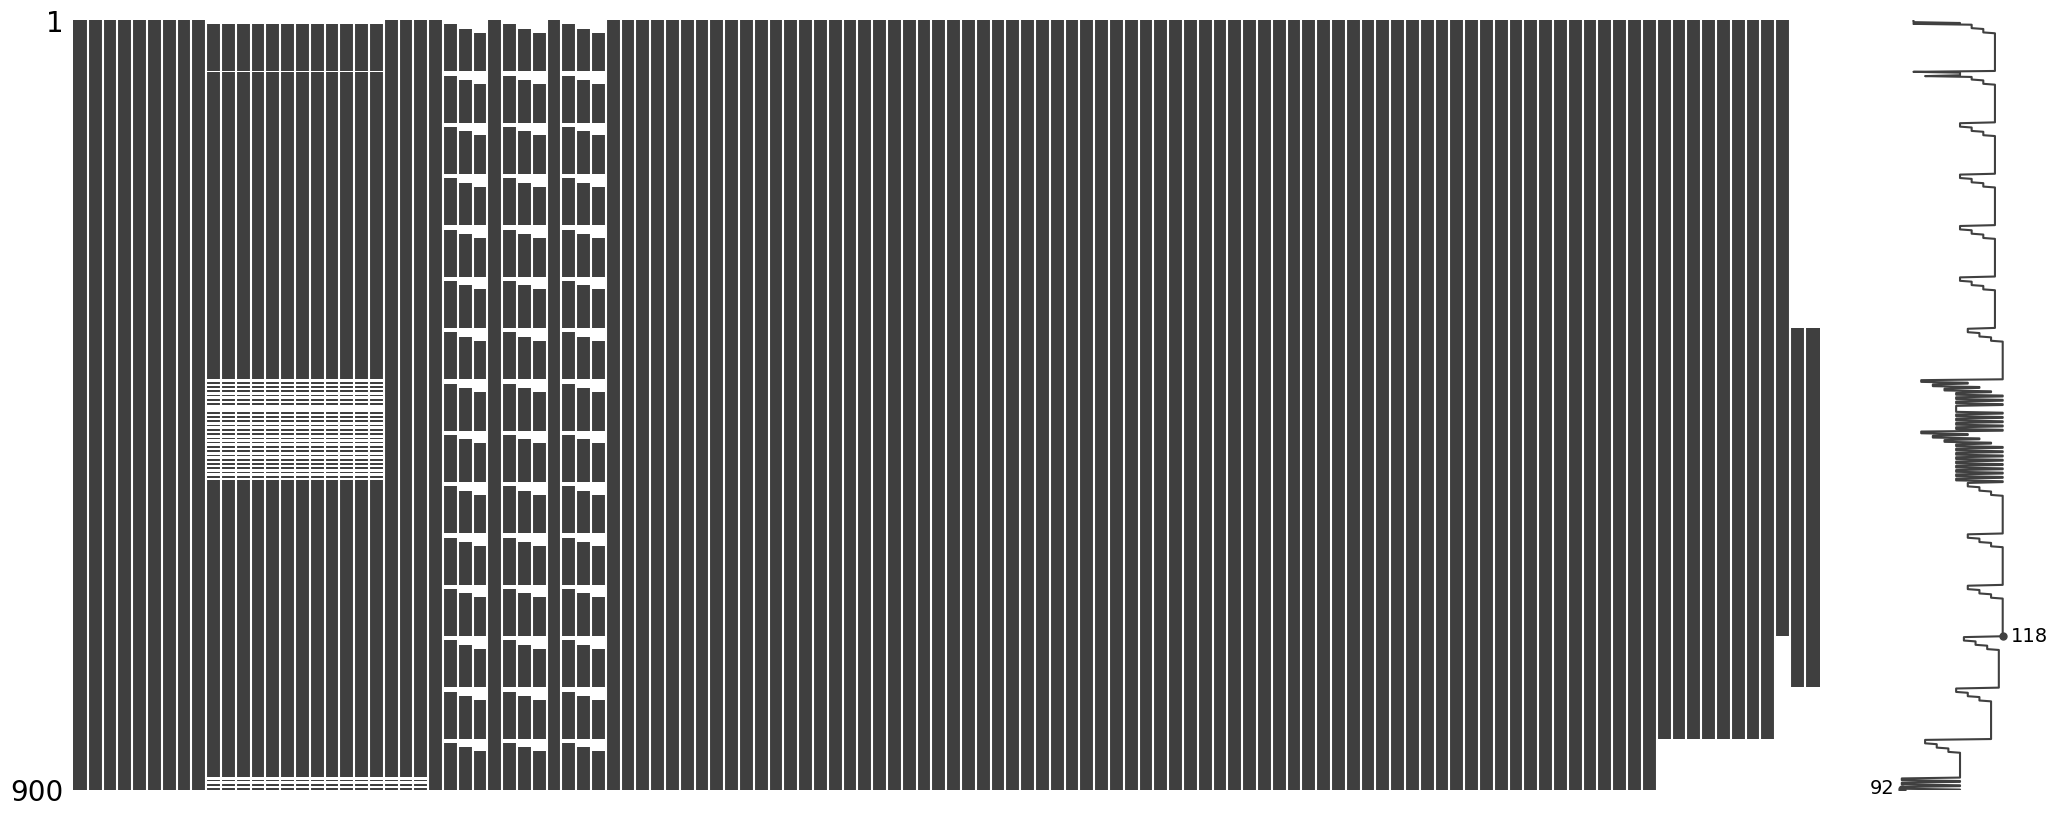

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
9,ndvi,9.8889
10,ndmi,9.8889
11,ndwi,9.8889
12,ndbi,9.8889
13,ndvi_mean,9.8889
...,...,...
113,F_Y_GE65,6.6667
114,F_TOTAL,6.6667
115,MIO_EUR,20.0000
116,L_TOTAL,53.3333


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_ID.unique()

In [7]:
data_p1 = []
data_p2 = []

for year in years[1:]:
    for region in nuts3_units:
        df_regional = dataset_monthly.loc[(dataset_monthly['NUTS3_ID'] == region)].copy()
        df_regional.reset_index(drop = True, inplace = True)

        df_period_1 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] == 1))].copy()
        df_period_2 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] <= 4))].copy()
        #df_period_2 = df_regional.loc[(df_regional['year'] == 2011) & (df_regional['month'] >= 2) & (df_regional['month'] <= 4)].copy()
        df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
        df_curr_year = df_regional.loc[(df_regional['year'] == year)].copy()

        x = df_curr_year['x'].mean()
        y = df_curr_year['y'].mean()

        ndvi_p1 = df_period_1['ndvi'].mean()
        ndwi_p1 = df_period_1['ndwi'].mean()
        ndmi_p1 = df_period_1['ndmi'].mean()
        ndbi_p1 = df_period_1['ndbi'].mean()

        ndvi_p2 = df_period_2['ndvi'].mean()
        ndwi_p2 = df_period_2['ndwi'].mean()
        ndmi_p2 = df_period_2['ndmi'].mean()
        ndbi_p2 = df_period_2['ndbi'].mean()
        #------------------------------------------------------
        lst_mean_p1 = df_period_1['lst_mean'].mean()
        lst_day_mean_p1 = df_period_1['lst_day_mean'].mean()
        lst_night_mean_p1 = df_period_1['lst_night_mean'].mean()
        lst_min_p1 = df_period_1['monthly_lst_min'].min()
        lst_max_p1 = df_period_1['monthly_lst_min'].max()

        lst_mean_p2 = df_period_2['lst_mean'].mean()
        lst_day_mean_p2 = df_period_2['lst_day_mean'].mean()
        lst_night_mean_p2 = df_period_2['lst_night_mean'].mean()
        lst_min_p2 = df_period_2['monthly_lst_min'].min()
        lst_max_p2 = df_period_2['monthly_lst_min'].max()
        #-------------------------------------------------------
        prec_mean_p1 = df_period_1['rainfall_mean'].mean()
        prec_acc_p1 = df_period_1['monthly_acc_prec'].sum()

        prec_mean_p2 = df_period_2['rainfall_mean'].mean()
        prec_acc_p2 = df_period_2['monthly_acc_prec'].sum()
        #-------------------------------------------------------
        mosq_mean_p1 = df_period_1['mosq_pred_mean'].mean()
        mosq_sum_p1 = df_period_1['mosq_pred_acc'].sum()

        mosq_mean_p2 = df_period_2['mosq_pred_mean'].mean()
        mosq_sum_p2 = df_period_2['mosq_pred_acc'].sum()
        #--------------------------------------------------------
        bio1 = df_prev_year.iloc[0]['bio1']
        bio2 = df_prev_year.iloc[0]['bio2']
        bio3 = df_prev_year.iloc[0]['bio3']
        bio4 = df_prev_year.iloc[0]['bio4']
        bio5 = df_prev_year.iloc[0]['bio5']
        bio6 = df_prev_year.iloc[0]['bio6']
        bio7 = df_prev_year.iloc[0]['bio7']
        bio8 = df_prev_year.iloc[0]['bio8']
        bio9 = df_prev_year.iloc[0]['bio9']
        bio10 = df_prev_year.iloc[0]['bio10']
        bio11 = df_prev_year.iloc[0]['bio11']
        bio12 = df_prev_year.iloc[0]['bio12']
        bio13 = df_prev_year.iloc[0]['bio13']
        bio14 = df_prev_year.iloc[0]['bio14']
        bio15 = df_prev_year.iloc[0]['bio15']
        bio16 = df_prev_year.iloc[0]['bio16']
        bio17 = df_prev_year.iloc[0]['bio17']
        bio18 = df_prev_year.iloc[0]['bio18']
        bio19 = df_prev_year.iloc[0]['bio19']
        #--------------------------------------------------------
        lc_prop1 = df_prev_year.iloc[0]['lc_prop1']
        lc_prop2 = df_prev_year.iloc[0]['lc_prop2']
        lc_prop3 = df_prev_year.iloc[0]['lc_prop3']
        lc_type1 = df_prev_year.iloc[0]['lc_type1']
        lc_type2 = df_prev_year.iloc[0]['lc_type2']
        lc_type3 = df_prev_year.iloc[0]['lc_type3']
        lc_type4 = df_prev_year.iloc[0]['lc_type4']
        lc_type5 = df_prev_year.iloc[0]['lc_type5']
        #--------------------------------------------------------
        distance_to_coast = df_prev_year.iloc[0]['distance_to_coast']
        distance_to_river = df_prev_year.iloc[0]['distance_to_river']
        slope_mean_1km = df_prev_year.iloc[0]['slope_mean_1km']
        aspect_mean_200m = df_prev_year.iloc[0]['aspect_mean_200m']
        elevation_mean_1km = df_prev_year.iloc[0]['elevation_mean_1km']
        hillshade_mean_1km = df_prev_year.iloc[0]['hillshade_mean_1km']
        fs_area_1km = df_prev_year.iloc[0]['fs_area_1km']
        flow_accu_200m = df_prev_year.iloc[0]['flow_accu_200m']

        distance_to_coast_std = df_prev_year.iloc[0]['distance_to_coast_std']
        distance_to_river_std = df_prev_year.iloc[0]['distance_to_river_std']
        slope_mean_1km_std = df_prev_year.iloc[0]['slope_mean_1km_std']
        aspect_mean_200m_std = df_prev_year.iloc[0]['aspect_mean_200m_std']
        elevation_mean_1km_std = df_prev_year.iloc[0]['elevation_mean_1km_std']
        hillshade_mean_1km_std = df_prev_year.iloc[0]['hillshade_mean_1km_std']
        fs_area_1km_std = df_prev_year.iloc[0]['fs_area_1km_std']
        flow_accu_200m_std = df_prev_year.iloc[0]['flow_accu_200m_std']
        #--------------------------------------------------------
        males_lt15 = df_prev_year.iloc[0]['M_Y_LT15']
        males_15t64 = df_prev_year.iloc[0]['M_Y15-64']
        males_gt65 = df_prev_year.iloc[0]['M_Y_GE65']
        males_total = df_prev_year.iloc[0]['M_TOTAL']

        females_lt15 = df_prev_year.iloc[0]['F_Y_LT15']
        females_15t64 = df_prev_year.iloc[0]['F_Y15-64']
        females_gt65 = df_prev_year.iloc[0]['F_Y_GE65']
        females_total = df_prev_year.iloc[0]['F_TOTAL']

        mio_eur = df_prev_year.iloc[0]['MIO_EUR']
        l_total = df_prev_year.iloc[0]['L_TOTAL']
        unl_total = df_prev_year.iloc[0]['UNL_TOTAL']
        #--------------------------------------------------------
        cases_total = df_curr_year['cases'].sum()
        cases_arr = df_curr_year.loc[(df_curr_year['month'] >= 5) & (df_curr_year['month'] <= 10)]['cases'].to_list()

        data_p1.append({'NUTS3_ID': region, 
                     'year': year, 
                     'x' : x,
                     'y': y,
                     'ndvi_p1': ndvi_p1,
                     'ndwi_p1': ndwi_p1,
                     'ndmi_p1': ndmi_p1,
                     'ndbi_p1': ndbi_p1,
                     'lst_mean_p1': lst_mean_p1,
                     'lst_day_mean_p1': lst_day_mean_p1,
                     'lst_night_mean_p1': lst_night_mean_p1,
                     'lst_min_p1': lst_min_p1,
                     'lst_max_p1': lst_max_p1,
                     'prec_mean_p1': prec_mean_p1,
                     'prec_acc_p1': prec_acc_p1,
                     'mosq_mean_p1': mosq_mean_p1,
                     'mosq_sum_p1': mosq_sum_p1,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })

        data_p2.append({'NUTS3_ID': region, 
                     'year': year,
                     'x' : x,
                     'y': y, 
                     'ndvi_p2': ndvi_p2,
                     'ndwi_p2': ndwi_p2,
                     'ndmi_p2': ndmi_p2,
                     'ndbi_p2': ndbi_p2,
                     'lst_mean_p2': lst_mean_p2,
                     'lst_day_mean_p2': lst_day_mean_p2,
                     'lst_night_mean_p2': lst_night_mean_p2,
                     'lst_min_p2': lst_min_p2,
                     'lst_max_p2': lst_max_p2,
                     'prec_mean_p2': prec_mean_p2,
                     'prec_acc_p2': prec_acc_p2,
                     'mosq_mean_p2': mosq_mean_p2,
                     'mosq_sum_p2': mosq_sum_p2,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })
        
p1_df = pd.DataFrame(data_p1)       
p2_df = pd.DataFrame(data_p2) 

In [8]:
p1_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL511,2010,26.176106,41.222160,0.294316,-0.196411,0.056235,-0.056235,7.355609,9.773284,4.937934,-5.993900,1.815500,7.682450,709.927967,1.158903,106.495098,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,31,36,30,12,12,3,5,8,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
1,EL512,2010,24.892059,41.169359,0.292108,-0.201448,0.070262,-0.070262,7.124092,10.575883,3.672300,-6.256500,3.180500,5.276282,487.474068,1.036694,95.412500,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,31,36,30,12,12,3,4,4,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,10590.0,37198.0,7334.0,55122.0,9955.0,36599.0,9263.0,55817.0,1544.09,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
2,EL513,2010,25.520366,41.111582,0.194590,-0.158813,0.019143,-0.019143,7.151957,10.404152,3.899762,-5.830323,4.038065,6.243957,576.604393,1.001387,92.129032,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,31,36,30,12,12,3,5,8,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,8312.0,36363.0,9590.0,54265.0,7809.0,37741.0,11914.0,57464.0,1637.96,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
3,EL514,2010,24.180725,41.300798,0.276954,-0.161306,0.079720,-0.079720,5.281963,8.523789,2.040138,-6.785583,0.716258,4.207020,388.777737,1.265642,116.649123,12.750000,18.333333,42.635659,817.284862,35.0,-8.0,43.0,3.000000,22.500000,22.500000,3.000000,1562.0,281.0,67.0,53.226270,609.0,267.0,322.0,609.0,31,10,10,4,4,6,4,4,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,6661.726102,977.423359,9.648629,60.382682,380.392072,15.747938,0.000407,492.988002,7608.0,29799.0,10403.0,47810.0,6962.0,29625.0,13770.0,50357.0,1314.36,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
4,EL515,2010,24.438568,40.915602,0.324922,-0.121260,0.155800,-0.155800,7.901349,11.364177,4.438522,-2.843659,2.990732,4.789590,442.471676,1.104773,101.743902,15.125000,18.416667,44.918699,803.154293,37.0,-4.0,41.0,5.833333,24.500000,24.833333,5.833333,1505.0,311.0,37.0,67.336002,690.0,201.0,220.0,690.0,31,20,30,9,9,4,1,1,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,5082.728847,1194.057645,9.940867,60.173946,241.561441,11.893370,0.000000,130.863872,10674.0,44339.0,13628.0,68641.0,9802.0,44104.0,17420.0,71326.0,2498.51,NaN,NaN,1,"[0, 0, 0, 0, 0, 1]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [9]:
p2_df

,NUTS3_ID,year,x,y,ndvi_p2,ndwi_p2,ndmi_p2,ndbi_p2,lst_mean_p2,lst_day_mean_p2,lst_night_mean_p2,lst_min_p2,lst_max_p2,prec_mean_p2,prec_acc_p2,mosq_mean_p2,mosq_sum_p2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL511,2010,26.176106,41.222160,0.318343,-0.212517,0.077105,-0.077105,8.204886,12.241577,4.168196,-5.993900,3.820600,7.555987,1353.549150,1.251566,226.598039,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,31,36,30,12,12,3,5,8,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
1,EL512,2010,24.892059,41.169359,0.291370,-0.180825,0.100195,-0.100195,8.215090,12.769228,3.660953,-6.256500,5.137000,6.147996,1094.550937,1.018347,184.412500,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,31,36,30,12,12,3,4,4,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,10590.0,37198.0,7334.0,55122.0,9955.0,36599.0,9263.0,55817.0,1544.09,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
2,EL513,2010,25.520366,41.111582,0.244569,-0.198352,0.036217,-0.036217,8.500071,13.132766,3.867375,-5.830323,4.723548,6.672889,1190.289606,1.000694,181.129032,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,31,36,30,12,12,3,5,8,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,11790.326771,999.501016,8.908693,55.271603,236.459919,8.920992,0.022934,179.980570,8312.0,36363.0,9590.0,54265.0,7809.0,37741.0,11914.0,57464.0,1637.96,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
3,EL514,2010,24.180725,41.300798,0.258130,-0.067990,0.161013,-0.161013,6.438106,10.569025,2.307187,-6.785583,4.403988,5.112103,910.447370,1.279175,231.994152,12.750000,18.333333,42.635659,817.284862,35.0,-8.0,43.0,3.000000,22.500000,22.500000,3.000000,1562.0,281.0,67.0,53.226270,609.0,267.0,322.0,609.0,31,10,10,4,4,6,4,4,10235.211338,1347.266180,14.339181,175.649354,681.171727,179.960721,0.000059,93.338294,6661.726102,977.423359,9.648629,60.382682,380.392072,15.747938,0.000407,492.988002,7608.0,29799.0,10403.0,47810.0,6962.0,29625.0,13770.0,50357.0,1314.36,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
4,EL515,2010,24.438568,40.915602,0.309457,-0.145683,0.130647,-0.130647,9.032821,13.171888,4.893754,-3.109024,6.234146,5.421746,965.535692,1.115617,202.121951,15.125000,18.416667,44.918699,803.154293,37.0,-4.0,41.0,5.833333,24.500000,24.833333,5.833333,1505.0,311.0,37.0,67.336002,690.0,201.0,220.0,690.0,31,20,30,9,9,4,1,1,8651.285469,1674.007433,13.512195,173.904275,330.955393,177.973580,0.000000,38.994123,5082.728847,1194.057645,9.940867,60.173946,241.561441,11.893370,0.000000,130.863872,10674.0,44339.0,13628.0,68641.0,9802.0,44104.0,17420.0,71326.0,2498.51,NaN,NaN,1,"[0, 0, 0, 0, 0, 1]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

<Axes: >

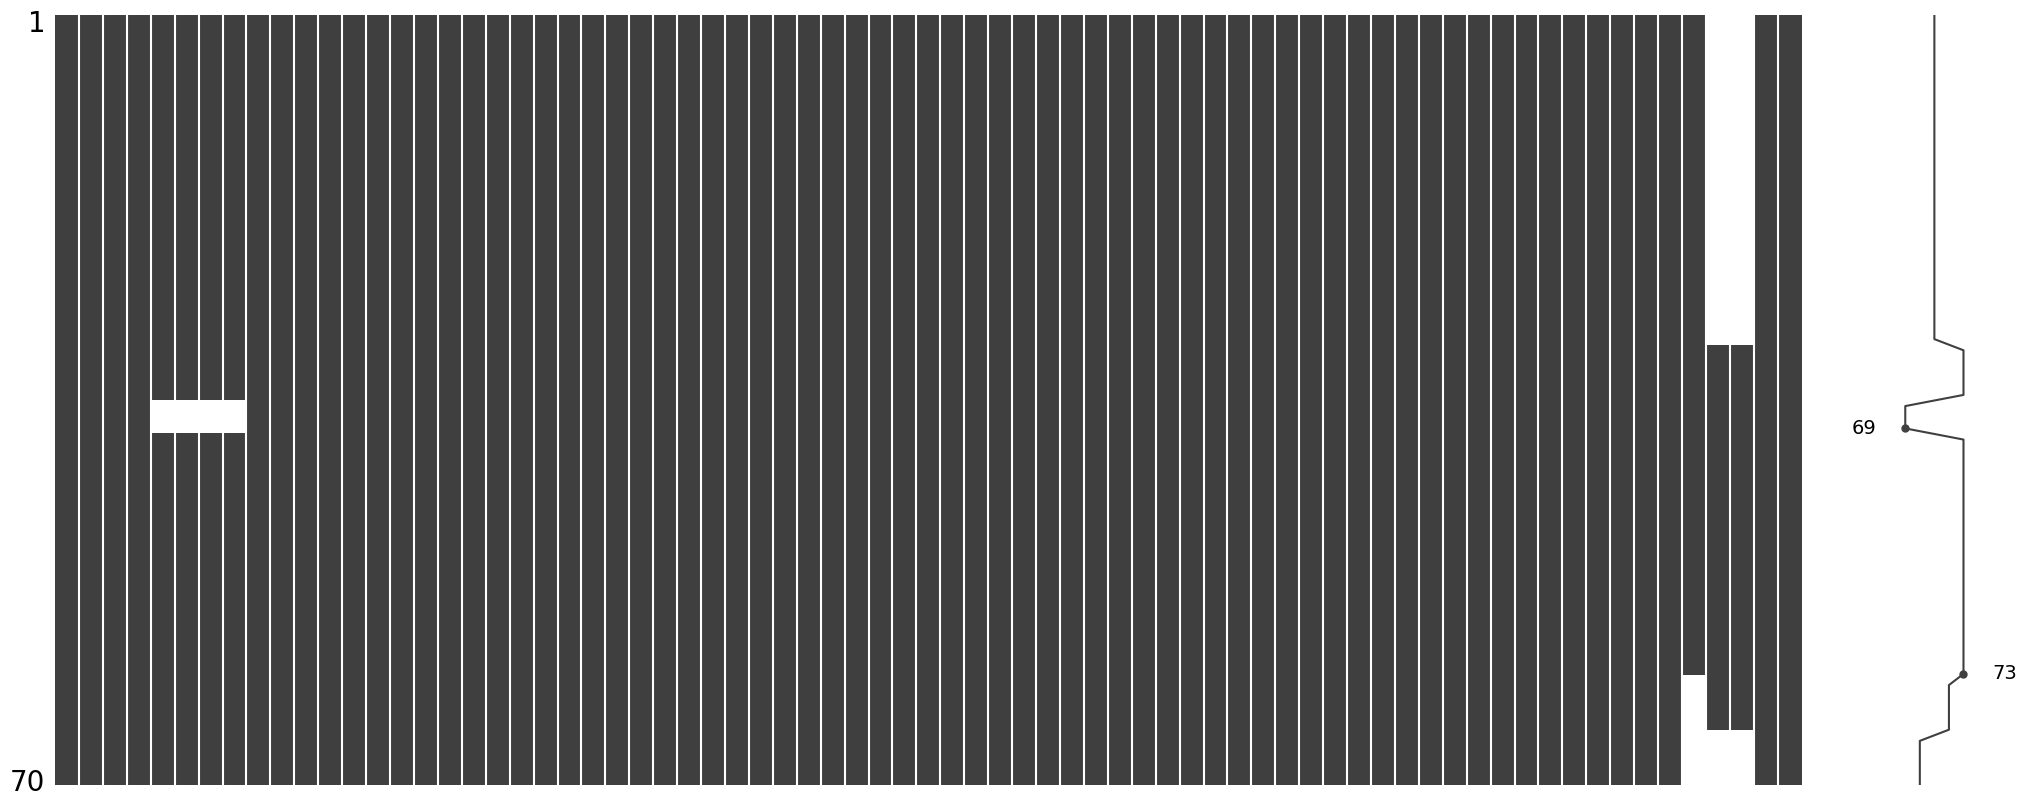

In [10]:
missingno.matrix(p1_df)

<Axes: >

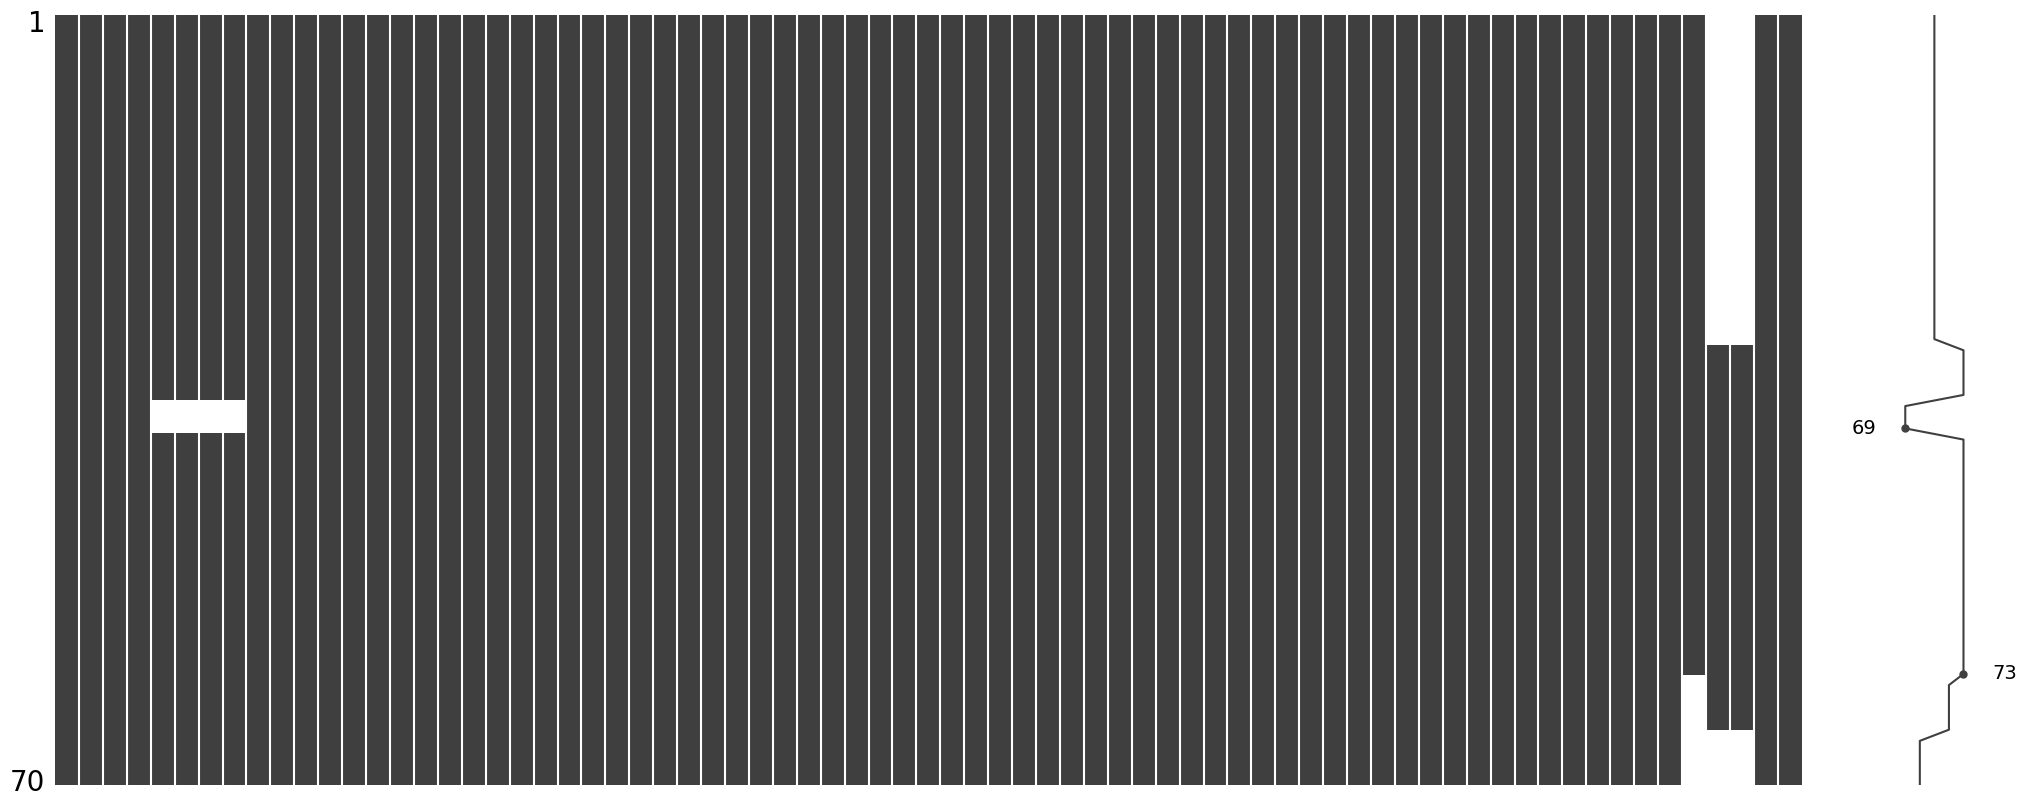

In [11]:
missingno.matrix(p2_df)

In [12]:
missing = describe_dataframe(p1_df, remove_zeros=True)
missing

,Column,Missing
4,ndvi_p1,4.2857
5,ndwi_p1,4.2857
6,ndmi_p1,4.2857
7,ndbi_p1,4.2857
68,mio_eur,14.2857
69,l_total,50.0000
70,unl_total,50.0000


In [13]:
missing = describe_dataframe(p2_df, remove_zeros=True)
missing

,Column,Missing
4,ndvi_p2,4.2857
5,ndwi_p2,4.2857
6,ndmi_p2,4.2857
7,ndbi_p2,4.2857
68,mio_eur,14.2857
69,l_total,50.0000
70,unl_total,50.0000


In [14]:
p1_df.cases_total.sum()

282

In [15]:
p2_df.cases_total.sum()

282

In [16]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'mio_eur']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['mio_eur']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [17]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'l_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['l_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [18]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'unl_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['unl_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

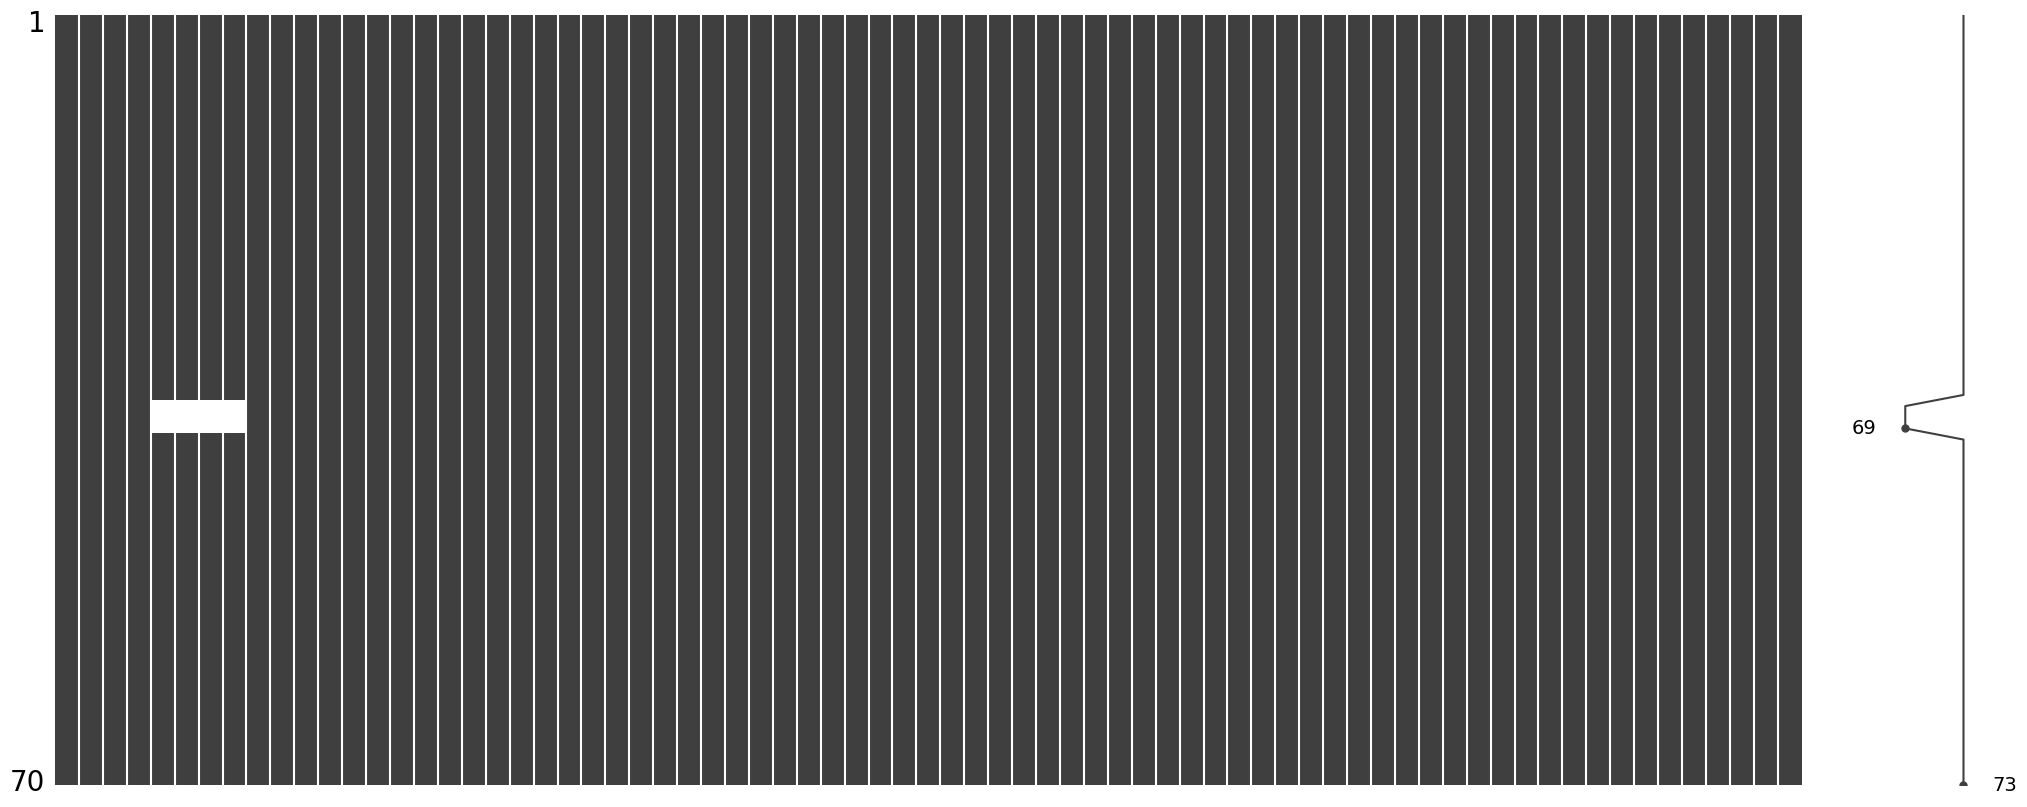

In [19]:
missingno.matrix(p1_df, label_rotation=90)

<Axes: >

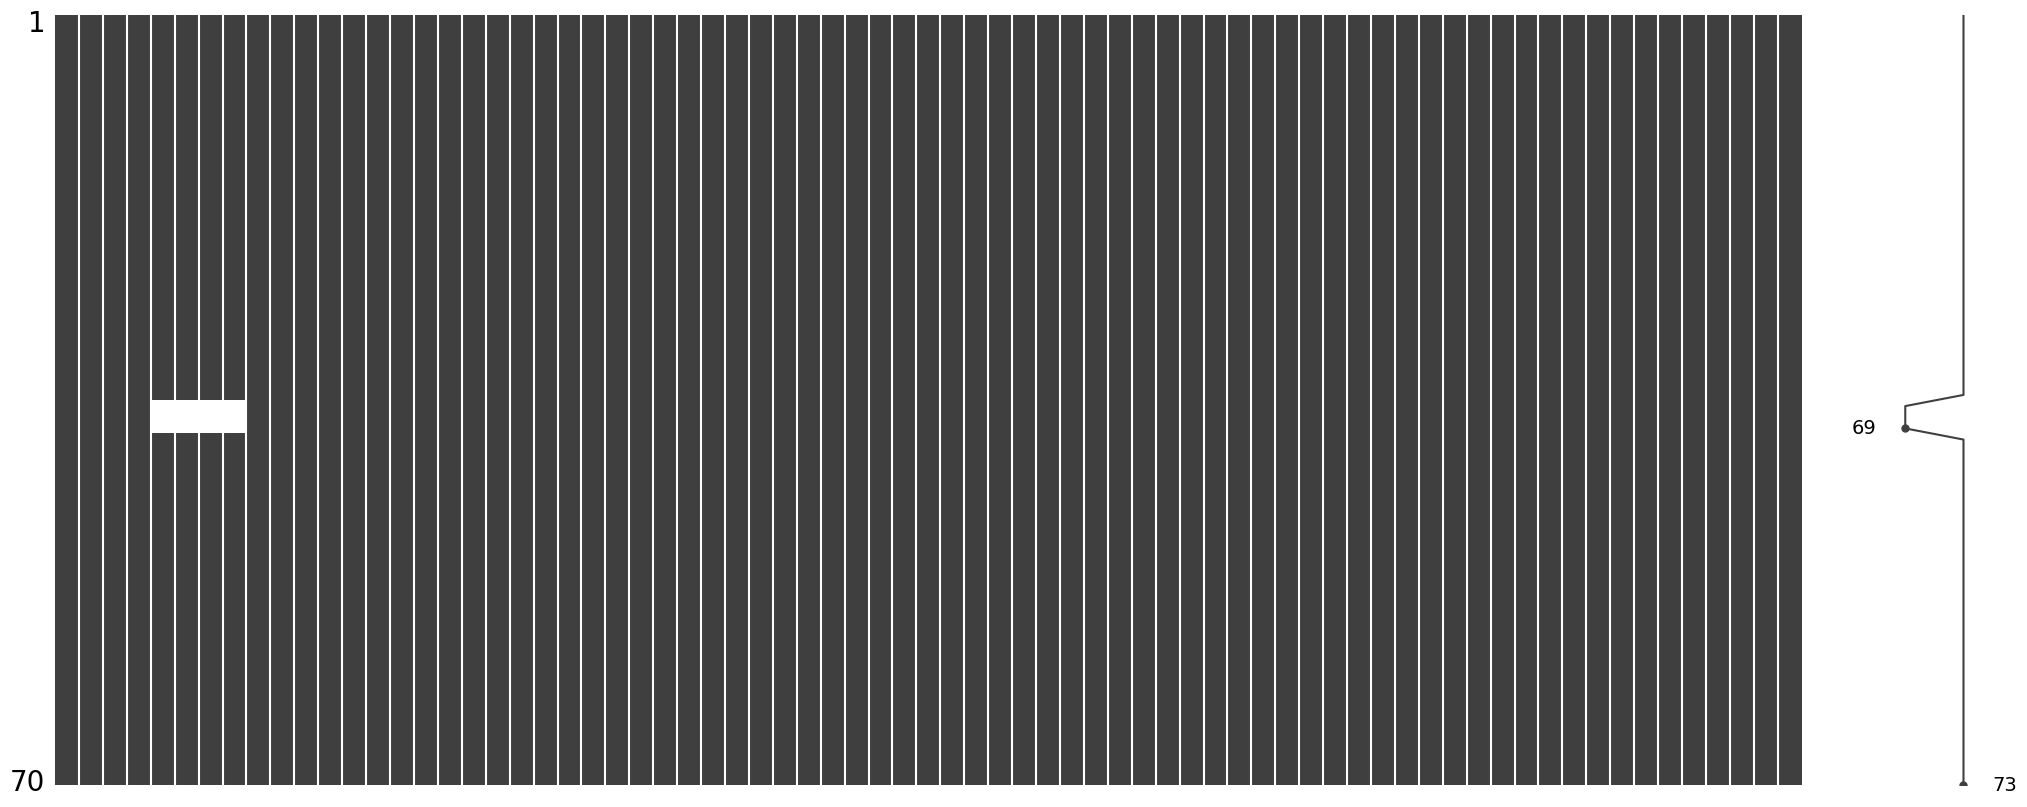

In [20]:
missingno.matrix(p2_df, label_rotation=90)

<Axes: >

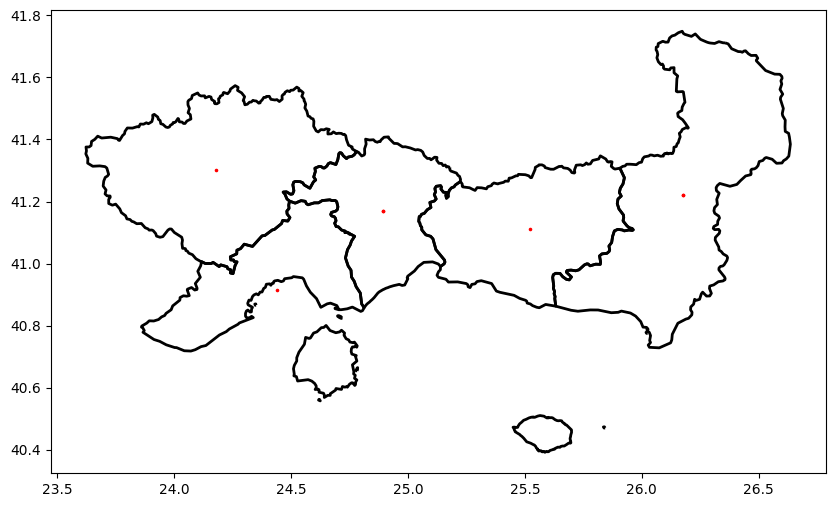

In [21]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(p1_df[['NUTS3_ID']], geometry=gpd.points_from_xy(p1_df.x, p1_df.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [22]:
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P1_2010_2023.csv", encoding = enc, index = False)
p2_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P2_2010_2023.csv", encoding = enc, index = False)